<a href="https://colab.research.google.com/github/harishmuh/Gene-Expression_Acute-Leukimia_MLClassification/blob/main/Heatmap_visualization_Acute_leukemia_AML_VS_ALL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heatmap visualization of significant genes (AML vs ALL)**

## **Context**

**Leukimia**

Leukimia is a type of cancer that affects blood and bone marrow (blood forming tissues). This cancer disrupts the normal function of the healthy blood cells that leads to the overproduction of abnormal white blood cells that crowd out healthy blood cells, which impairs the body's ability to fight infections and can interfere with the production of red blood cells and platelets.
According to the World Health Organization (WHO), leukemia accounts for 2.5% to 3% of all cancer deaths globally. In addition, Global Burden of Disease (GBD) Study 2020 estimates that around 310,000 deaths annually due to leukemia worldwide. The mortality rate of this cancer varies significantly by region and limited access to healthcare facilities often leads to higher mortality rates due to late diagnosis and inadequate treatment.

**Hematopoietic stem cell**

Hematopoietic stem cell is an immature cell that can develop into all type of blood cells, including white blood cells. Hematopoietic stem cells are found in the peripheral blood and the bone marrow. Based on the origins of hematopoietic cells, acute leukimia can be divided into AML (Acute Myeloid Leukimia) and ALL (Acute Lymphoblastic Leukimia).

![hematopoietic stem cell](https://nci-media.cancer.gov/pdq/media/images/526219-571.jpg)

[Hematopietic cell - National Institute of Health](https://www.cancer.gov/publications/dictionaries/cancer-terms/def/hematopoietic-stem-cell)

**AML**
* Associated with high expression of genes related to myeloid cells, which are cells that normally turn into red blood cells, platelets, and some types of white blood cells (like neutrophils).
* The leukemia cells are myeloblasts, which may have special features like Auer rods (tiny needle-like structures seen under a microscope).

**ALL**
* Characterized by genes expressed in the lymphoid cells, which are cells that normally turn into lymphocytes (a type of white blood cell that helps fight infections and builds immunity).
* The leukemia cells are lymphoblasts, which are simpler-looking cells without special features like Auer rods.

**Clinical presentation of ALL and AML**

| **Feature**                 | **ALL (Acute Lymphoblastic Leukemia)**                                | **AML (Acute Myeloid Leukemia)**                                 |
|-----------------------------|----------------------------------------------------------------------|-----------------------------------------------------------------|
| **Age group**               | Common in children and teenagers.                                   | Common in adults, especially older adults.                     |
| **Lymph node swelling**     | More common, noticeable in the neck, underarms, or groin.            | Rarely significant.                                             |
| **Bone pain**               | Often severe, especially in large bones (e.g., legs, arms).          | Less common and less specific.                                  |
| **Bleeding and bruising**   | Occurs but usually less severe.                                      | More severe; includes frequent gum bleeding and skin spots.     |
| **CNS involvement**         | Can involve brain or spinal cord, causing headaches or seizures.     | Rare at diagnosis.                                              |
| **Gum involvement**         | Rarely affected.                                                    | Can cause gum swelling or bleeding.                             |
| **Skin changes**            | Rarely causes skin changes.                                         | May cause lumps or reddish spots under the skin (leukemia cutis). |


**Challenges in differentiating ALL and AML**
  
The appearance and symptoms of ALL and AML are highly similar. Both types share some clinical features, but they differ fundamentally in terms of cellular origin, progression, treatment protocols, and prognosis. These ALL and AML can present with similar symptoms such as fatigue, frequent infections, fever, bleeding, bruising, and pallor (caused by anemia, low platelets, or dysfunctional white blood cells). Unfortunately, the cure rate is remarkably diminished when ALL therapy is used for AML. Chemotherapy for ALL requires chemical substances that different with AML. In addition,  Thus, accurate distinction of acute leukemias is crucial for successful treatment. Since the mere inspection of the appearance of acute leukemias for classification has significant limitations, more systematic approach of gene expression monitoring is used.


**Microarray Gene Expression Data**

Microarray technology offers a high-throughput, comprehensive snapshot of gene expression levels in cells. AML and ALL origins from distinct blood cell lineages—myeloid and lymphoid progenitors, which express different sets of genes. Microarray analysis can capture these molecular differences, providing a more objective basis for classification.

### **Objective**
* To visualize the significant different of gene expression between acute myeloid leukemia (AML) and acute lymphoblastic leukemia (ALL) in heatmap, clustermap,and dendogram.

In [1]:
# Importing library
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind, f_oneway
from statsmodels.stats.multitest import fdrcorrection

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from collections import Counter

from imblearn.over_sampling import SMOTE

import random

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

In [2]:
# Loading dataset

# Url
url_actual_label = 'https://raw.githubusercontent.com/harishmuh/Gene-Expression_Acute-Leukimia_MLClassification/refs/heads/main/actual.csv'
url_train = 'https://raw.githubusercontent.com/harishmuh/Gene-Expression_Acute-Leukimia_MLClassification/refs/heads/main/data_set_ALL_AML_train.csv'
url_test = 'https://raw.githubusercontent.com/harishmuh/Gene-Expression_Acute-Leukimia_MLClassification/refs/heads/main/data_set_ALL_AML_independent.csv'

# Load from url
labels = pd.read_csv(url_actual_label)
df_train = pd.read_csv(url_train)
df_test = pd.read_csv(url_test)

print(labels.shape)
print(df_train.shape)
print(df_test.shape)

(72, 2)
(7129, 78)
(7129, 70)


## **Data cleaning**

In [3]:
# Remove call columns in training dataset
columns_to_remove_train = [col for col in df_train if 'call' in col]
train = df_train.drop(columns_to_remove_train, axis=1)

# Remove call columns in testing dataset
columns_to_remove_test = [col for col in df_test if 'call' in col]
test = df_test.drop(columns_to_remove_test, axis=1)

In [4]:
# Transpose row and columns in training set
X_train = train.T

# Transpose row and columns in testing set
X_test = test.T

Let's first designate the second row containing the gene accession numbers as the column names. Then, remove both the first two rows of Gene Description and Gene Accession Number.

In [5]:
# Set the second row (Gene Accession Number) as the column names
X_train.columns = X_train.iloc[1]  # for training set
X_test.columns = X_test.iloc[1]  # for testing set

# Drop the first two rows (Gene Description and Gene Accession Number) and reindex
X_train = X_train.iloc[2:].reset_index(drop=True)  # for training set
X_test = X_test.iloc[2:].reset_index(drop=True)  # for testing set

print(X_train.shape)
print(X_test.shape)

(38, 7129)
(34, 7129)


As most libraries work with numerical data, let's convert data values to numeric.

In [6]:
# Convert data values to numeric for training set
X_train = X_train.apply(pd.to_numeric, errors='coerce')

# Convert data values to numeric for testing set
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [7]:
# Check labels
labels.head()

,patient,cancer
0,1,ALL
1,2,ALL
2,3,ALL
3,4,ALL
4,5,ALL


## **Merging data**

We will first merge all the data of training set, testing set, and labels. Then, check for nulls.

In [8]:
# Merge all dataset
merged_X = pd.concat([X_train, X_test], ignore_index=True, axis=0)
merged_XY = pd.concat([merged_X, labels], axis=1)

print(merged_XY.shape)
merged_XY.head()

(72, 7131)


,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,patient,cancer
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,-125,389,-37,793,329,36,191,-37,1,ALL
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,-36,442,-17,782,295,11,76,-14,2,ALL
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,33,168,52,1138,777,41,228,-41,3,ALL
3,-135,-114,265,12,-419,-585,158,-253,49,31,...,218,174,-110,627,170,-50,126,-91,4,ALL
4,-106,-125,-76,168,-230,-284,4,-122,70,252,...,57,504,-26,250,314,14,56,-25,5,ALL


## **Missing values**

In [9]:
# Check for nulls
null_counts = merged_XY.isnull().sum().max()

print('Columns with Null Values:')
print(null_counts)

Columns with Null Values:
0


## **Imbalanced data**

In [10]:
# Check for label imbalance
merged_XY['cancer'].value_counts()

,count
cancer,
ALL,47
AML,25


We have much more ALL patients than AML patients. Let's also convert labels to numeric values with ALL as 0 and AML as 1.

In [11]:
# Replace values in the 'cancer' column with 0 for 'ALL' and 1 for 'AML'
cancer_mapping = {'ALL': 0, 'AML': 1}
merged_XY['cancer'] = merged_XY['cancer'].map(cancer_mapping)

In [12]:
print(merged_XY.shape)
merged_XY.head()

(72, 7131)


,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,patient,cancer
0,-214,-153,-58,88,-295,-558,199,-176,252,206,...,-125,389,-37,793,329,36,191,-37,1,0
1,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,-36,442,-17,782,295,11,76,-14,2,0
2,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,33,168,52,1138,777,41,228,-41,3,0
3,-135,-114,265,12,-419,-585,158,-253,49,31,...,218,174,-110,627,170,-50,126,-91,4,0
4,-106,-125,-76,168,-230,-284,4,-122,70,252,...,57,504,-26,250,314,14,56,-25,5,0


## **Normalization**

Since there are no null values, we don't need to worry about them. Now, as t-tests and many machine learning models perform better with normalized data, let's scale the data. We will use the dataframe 'merged_XY'. However, since label columns do not need to be scaled, we will first drop the label columns and then scale only the gene columns.

In [13]:
# Exclude patient and cancer columns
gene_columns = merged_XY.columns.drop(['patient', 'cancer'])
merged_X = merged_X[gene_columns]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the data (calculate mean and standard deviation)
scaler.fit(merged_X)

# Transform the data using the fitted scaler
normalized_merged_X = scaler.transform(merged_X)

# Convert back to pandas DataFrame
normalized_merged_X = pd.DataFrame(normalized_merged_X, columns=gene_columns)

# Concatenate the normalized gene expression data with the patient and cancer columns
normalized_merged_XY = pd.concat([normalized_merged_X, merged_XY[['patient', 'cancer']]], axis=1)

Later in t-test, we need separate data of ALL and AML patients. Thus, let's create the two separate normalized dataframes.

In [14]:
# Create separate normalized DataFrames for ALL and AML patients
normalized_merged_XY_ALL = normalized_merged_XY[normalized_merged_XY['cancer'] == 0]
normalized_merged_XY_AML = normalized_merged_XY[normalized_merged_XY['cancer'] == 1]

print(normalized_merged_XY_ALL.shape)
print(normalized_merged_XY_AML.shape)

(47, 7131)
(25, 7131)


## **Statistical analysis (t-test)**

We want to identify genes that play a crucial role in distinguishing between ALL and AML. To achieve this, we need to select genes where there is a significant difference between the means of the two groups. The Student's t-test is a statistical hypothesis test used to determine if there is a significant difference between the means of two groups. The t-test produces a t-value, which measures the difference between the means of the two groups relative to the variation in the data. The t-value is then used to calculate the p-value, which represents the probability of observing the observed difference in means (or more extreme) if the null hypothesis (no difference in means) is true. A significance level of p-value was chosen, commonly 0.05, to determine if the observed difference in means is statistically significant. If the p-value is less than the chosen significance level, then the null hypothesis is rejected, and the gene is considered significantly differentially expressed between the two groups. The smaller the p-value, the stronger the evidence against the null hypothesis, indicating that there is a significant difference between the groups.

In [15]:
# Drop 'patient' and 'cancer' columns for each normalized_merged_XY_ALL and normalized_merged_XY_AML
normalized_merged_X_ALL = normalized_merged_XY_ALL.drop(['patient', 'cancer'], axis=1)
normalized_merged_X_AML = normalized_merged_XY_AML.drop(['patient', 'cancer'], axis=1)

Since we do not need the label columns, we have removed those columns from both ALL and AML datasets. Now, let's compute t-value and p-value for each gene and create dataframes for each of them.

**T-test**

In [16]:
# Perform t-test for each gene
results = []
for gene in normalized_merged_X_ALL.columns:
    t_value, p_value = ttest_ind(normalized_merged_X_ALL[gene], normalized_merged_X_AML[gene], equal_var=False)
    results.append((gene, t_value, p_value))

# Convert results list to DataFrame
df_results = pd.DataFrame(results, columns=['Gene Accession Number', 'T_Value', 'P_Value'])

# Adjust p-values for multiple testing using False Discovery Rate (FDR) correction
rejected, adjusted_p_values = fdrcorrection(df_results['P_Value'])

In [17]:
df_results.head()

,Gene Accession Number,T_Value,P_Value
0,AFFX-BioB-5_at,-1.025408,0.309136
1,AFFX-BioB-M_at,-1.379648,0.172679
2,AFFX-BioB-3_at,-1.011032,0.315506
3,AFFX-BioC-5_at,-2.422568,0.018676
4,AFFX-BioC-3_at,0.029392,0.976665


## **Heat map for ALL patients**

**Filtering out significant genes for the ALL and AML classification**

We will filter genes with p-values less than 0.05, then sort them based on the p-values. Smaller p-value means that it has a bigger importance on distinguishing between ALL and AML patients.

In [18]:
# Set the threshold for significance level
threshold = 0.05

# Get the list of significant genes based on the threshold
significant_genes = df_results[rejected & (adjusted_p_values < threshold)]

# Sort significant genes based on p-values
significant_genes = significant_genes.sort_values(by='P_Value')

# Add rank to significant genes DataFrame
significant_genes['Rank'] = significant_genes['P_Value'].rank()

# Display the results
print("Total Genes: 7129")
print("Significant Genes (T-test):", len(significant_genes))

Total Genes: 7129
Significant Genes (T-test): 34


In [19]:
significant_genes_Acc = significant_genes['Gene Accession Number']

# Extracting gene expression data
significant_genes_data_all = normalized_merged_XY_ALL[significant_genes_Acc]
significant_genes_data_aml = normalized_merged_XY_AML[significant_genes_Acc]

Heatmap of 34 filtered genes for ALL

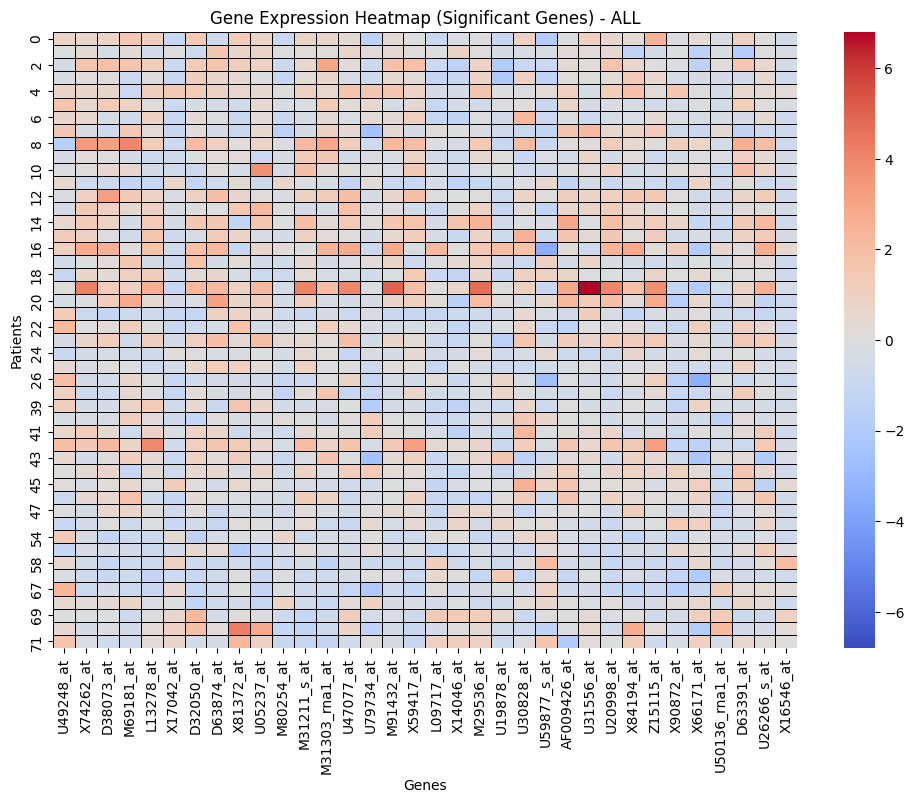

In [20]:
# For the comparison, use the same maximum absolute expression value for ALL and AML patients
max_abs_value_all = max(abs(significant_genes_data_all.values.max()), abs(significant_genes_data_all.values.min()))

# Generate heatmap for ALL patients
plt.figure(figsize=(12, 8))
sns.heatmap(significant_genes_data_all, cmap='coolwarm', linewidths=0.5, linecolor='black', vmin=-max_abs_value_all, vmax=max_abs_value_all, center=0)
plt.title('Gene Expression Heatmap (Significant Genes) - ALL')
plt.xlabel('Genes')
plt.ylabel('Patients')
plt.show()

Heatmap of 34 filtered genes for AML

## **Cluster map for ALL patients**

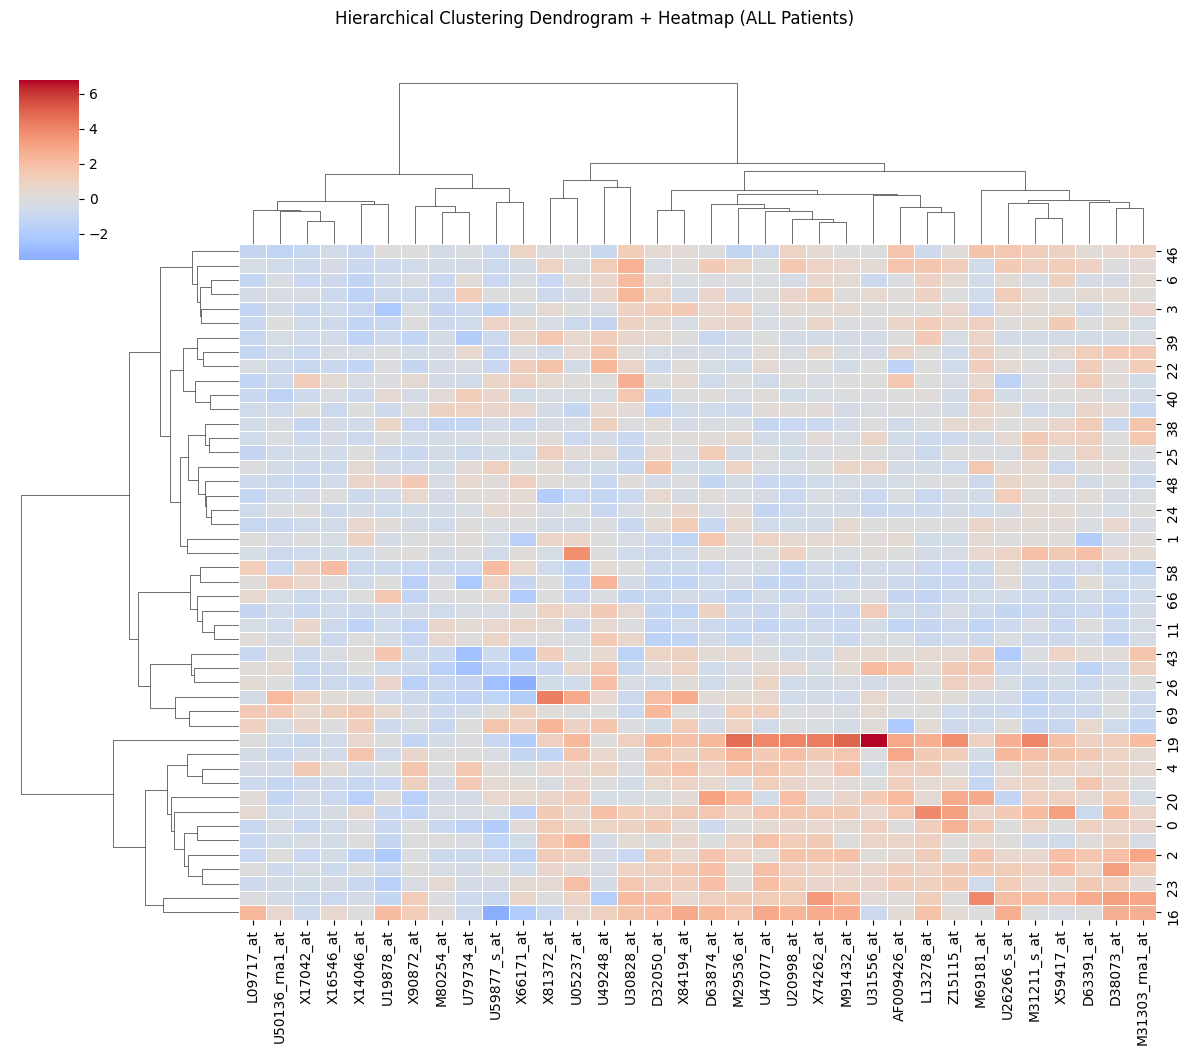

In [21]:
# Cluster map # ALL

import seaborn as sns
import matplotlib.pyplot as plt

# Clustering dendrogram + heatmap for ALL patients
sns.clustermap(significant_genes_data_all,
               method='ward',        # Hierarchical clustering method
               metric='euclidean',   # Distance metric
               cmap='coolwarm',
               linewidths=0.5,
               figsize=(12, 10),
               col_cluster=True,     # Cluster genes (columns)
               row_cluster=True,     # Cluster patients (rows)
               center=0)

plt.suptitle("Hierarchical Clustering Dendrogram + Heatmap (ALL Patients)", y=1.05)
plt.show()


Cluster map displays some genes expressed strongly in ALL patients

## **Dendogram for ALL Patients**

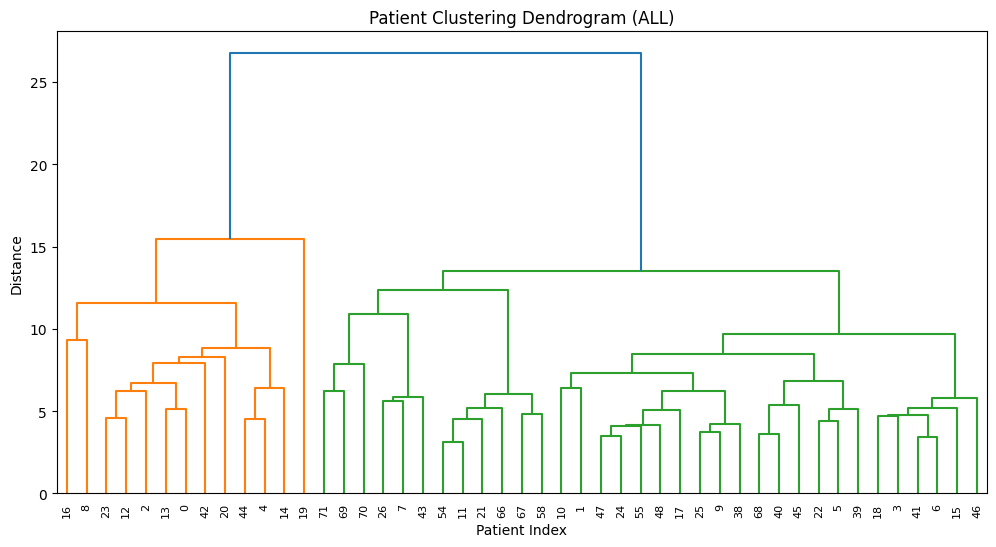

In [22]:
# Patient cluster for dendogram # ALL
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Compute linkage matrix
linked = linkage(significant_genes_data_all, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           labels=significant_genes_data_all.index,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Patient Clustering Dendrogram (ALL)')
plt.xlabel('Patient Index')
plt.ylabel('Distance')
plt.show()


## **Heat map for AML patients**

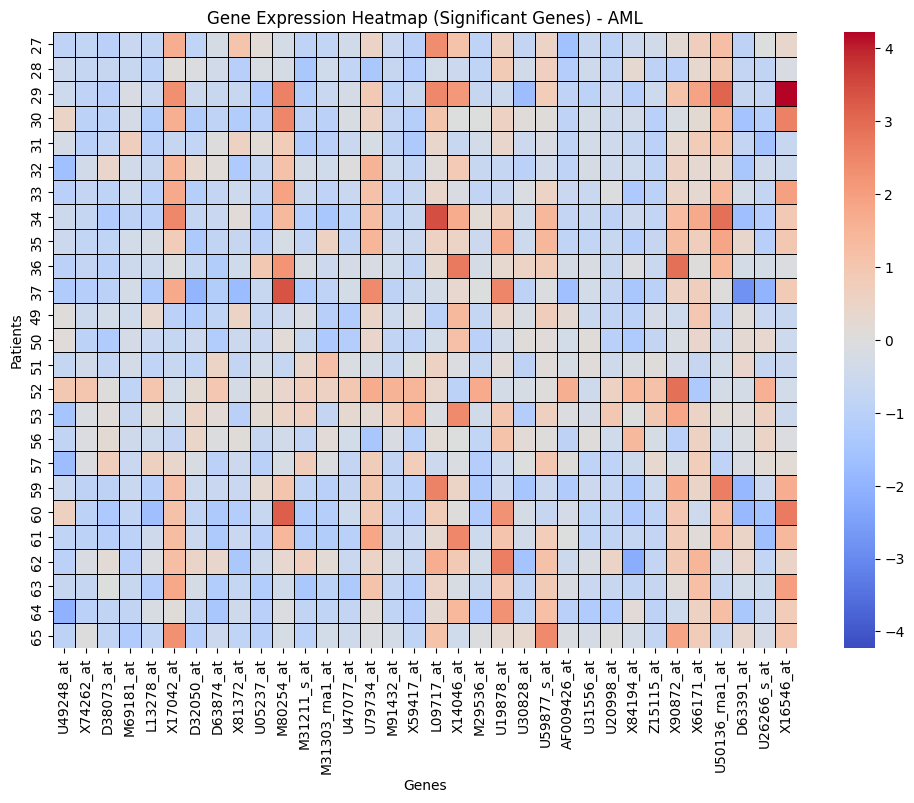

In [23]:
max_abs_value_aml = max(abs(significant_genes_data_aml.values.max()), abs(significant_genes_data_aml.values.min()))

plt.figure(figsize=(12, 8))
sns.heatmap(significant_genes_data_aml, cmap='coolwarm', linewidths=0.5, linecolor='black',
            vmin=-max_abs_value_aml, vmax=max_abs_value_aml, center=0)
plt.title('Gene Expression Heatmap (Significant Genes) - AML')
plt.xlabel('Genes')
plt.ylabel('Patients')
plt.show()


## **Cluster map for AML patients**

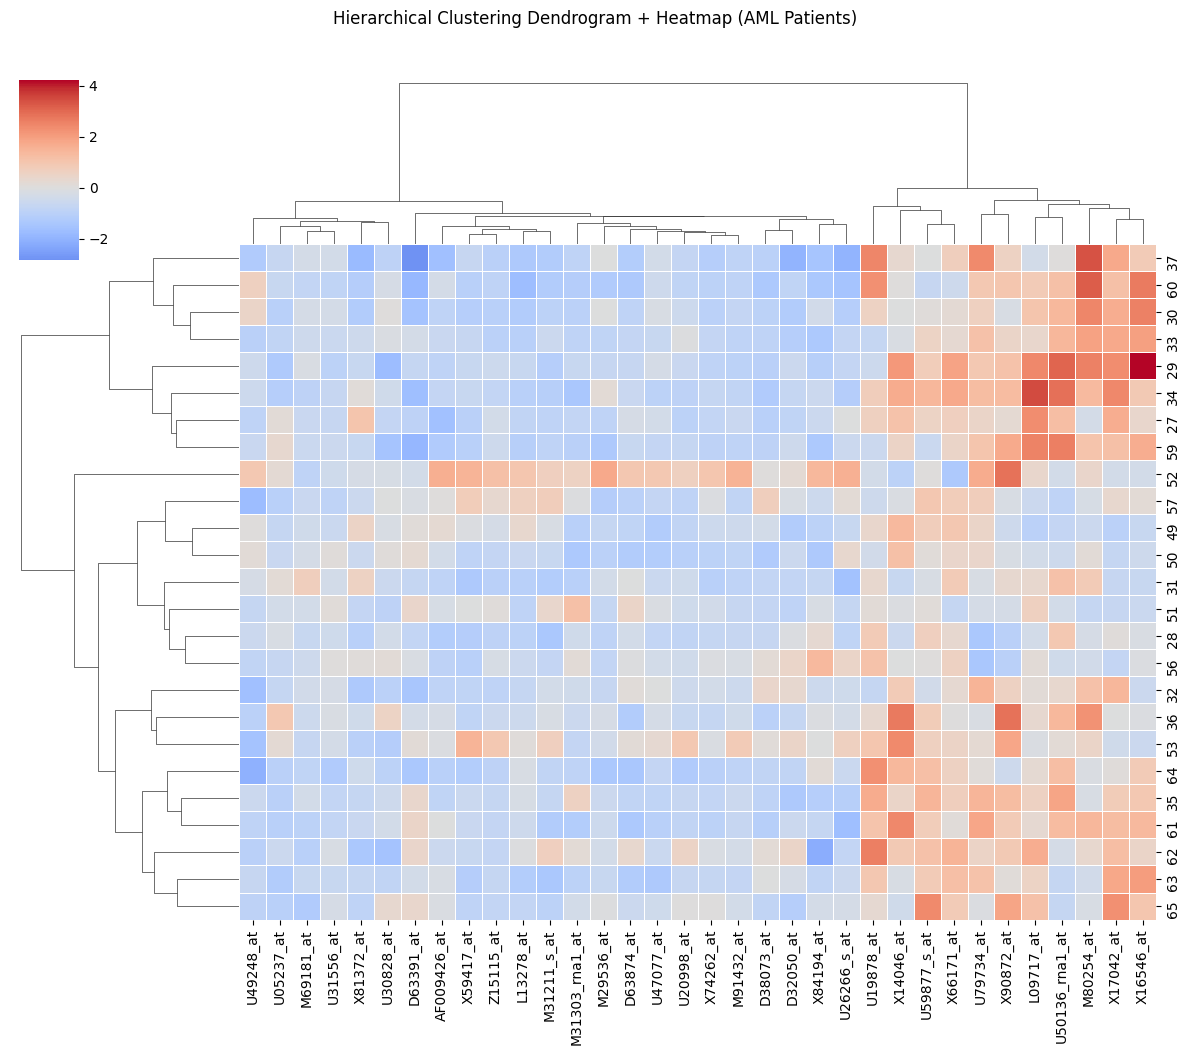

In [24]:
# Cluster map AML
sns.clustermap(significant_genes_data_aml,
               method='ward',
               metric='euclidean',
               cmap='coolwarm',
               linewidths=0.5,
               figsize=(12, 10),
               col_cluster=True,
               row_cluster=True,
               center=0)

plt.suptitle("Hierarchical Clustering Dendrogram + Heatmap (AML Patients)", y=1.05)
plt.show()


## **Dendogram for ALL patients**

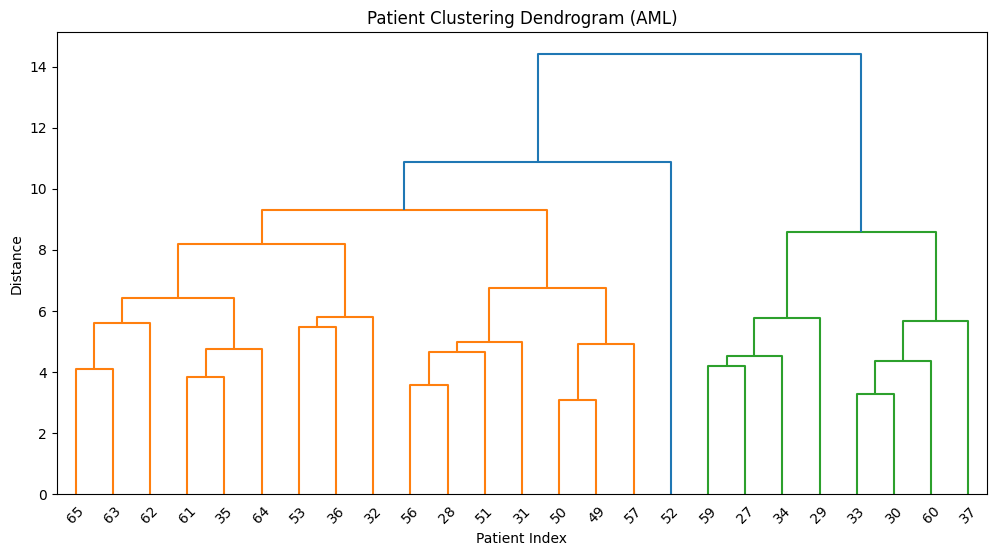

In [25]:
# Patient cluster for dendogram # AML
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Compute linkage matrix
linked = linkage(significant_genes_data_aml, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='top',
           labels=significant_genes_data_aml.index,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Patient Clustering Dendrogram (AML)')
plt.xlabel('Patient Index')
plt.ylabel('Distance')
plt.show()

In general, more warm color can be observed in ALL patients, whereas more cool color can be observed in AML patients. This suggests increased gene expression level in ALL patients. The color difference is particularly noticeable among the top genes on the left side of the x-axis.

**Extraction of data corresponding to the TOP3 key genes**

Let's utilize the top 3 significant genes for the classification. We will extract the corresponding data from the normalized dataset 'normalized_merged_XY'.

In [26]:
significant_genes.drop(['T_Value', 'P_Value'], axis=1, inplace=True)
significant_genes.head(3)

,Gene Accession Number,Rank
3300,U49248_at,1.0
4534,X74262_at,2.0
5253,D38073_at,3.0


## **Histogram and KDE plot for the key genes**

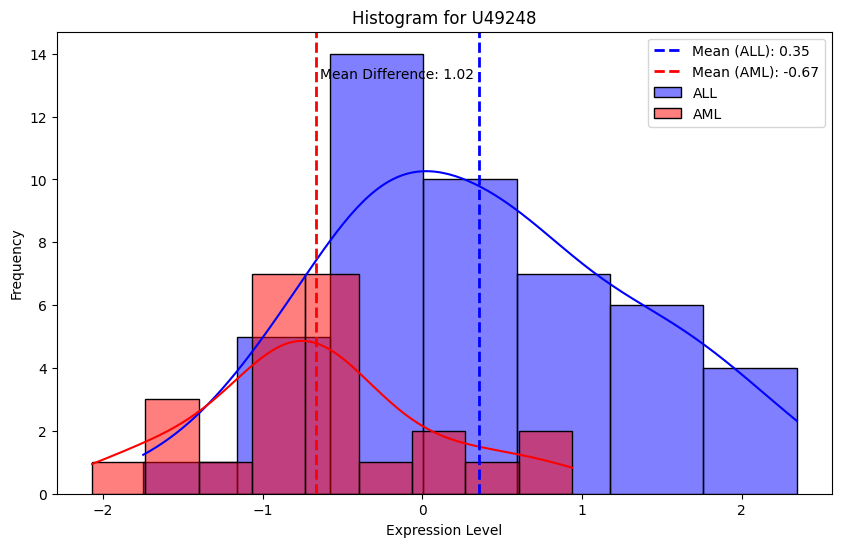

In [27]:
# Select gene expression data for both cancer types
gene_selected = 'U49248_at'
gene_selected_data_all = normalized_merged_XY_ALL[gene_selected]
gene_selected_data_aml = normalized_merged_XY_AML[gene_selected]

# Calculate mean expression for both cancer types
mean_expression_all = gene_selected_data_all.mean()
mean_expression_aml = gene_selected_data_aml.mean()

# Calculate mean difference
mean_difference = abs(mean_expression_all - mean_expression_aml)

# Plot histogram for both cancer types
plt.figure(figsize=(10, 6))

# Plot histogram for ALL
sns.histplot(gene_selected_data_all, color='blue', label='ALL', kde=True)

# Plot histogram for AML
sns.histplot(gene_selected_data_aml, color='red', label='AML', kde=True)

# Annotate mean values
plt.axvline(mean_expression_all, color='blue', linestyle='dashed', linewidth=2, label=f'Mean (ALL): {mean_expression_all:.2f}')
plt.axvline(mean_expression_aml, color='red', linestyle='dashed', linewidth=2, label=f'Mean (AML): {mean_expression_aml:.2f}')

# Annotate mean difference
plt.text((mean_expression_all + mean_expression_aml) / 2, plt.gca().get_ylim()[1]*0.9, f'Mean Difference: {mean_difference:.2f}', ha='center')

# Set labels and title
plt.xlabel('Expression Level')
plt.ylabel('Frequency')
plt.title('Histogram for U49248')

# Add legend
plt.legend()

# Show plot
plt.show()

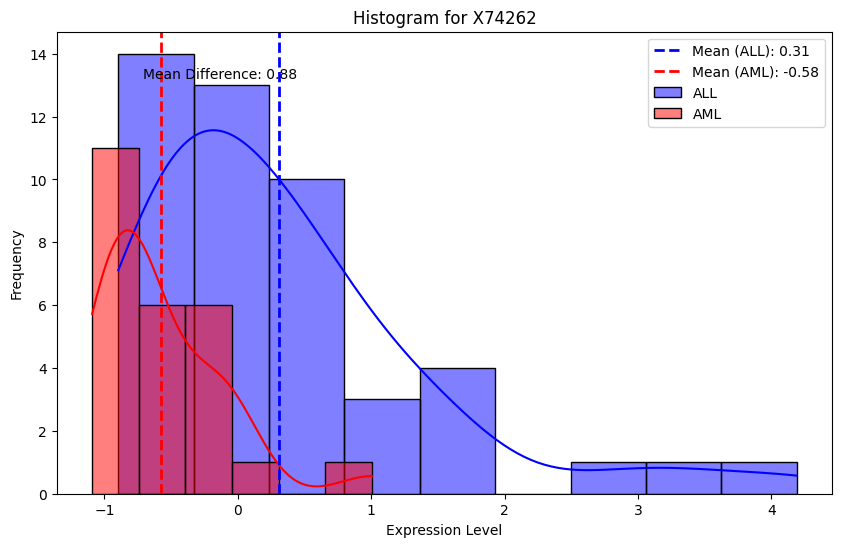

In [28]:
# Select gene expression data for both cancer types
gene_selected = 'X74262_at'
gene_selected_data_all = normalized_merged_XY_ALL[gene_selected]
gene_selected_data_aml = normalized_merged_XY_AML[gene_selected]

# Calculate mean expression for both cancer types
mean_expression_all = gene_selected_data_all.mean()
mean_expression_aml = gene_selected_data_aml.mean()

# Calculate mean difference
mean_difference = abs(mean_expression_all - mean_expression_aml)

# Plot histogram for both cancer types
plt.figure(figsize=(10, 6))

# Plot histogram for ALL
sns.histplot(gene_selected_data_all, color='blue', label='ALL', kde=True)

# Plot histogram for AML
sns.histplot(gene_selected_data_aml, color='red', label='AML', kde=True)

# Annotate mean values
plt.axvline(mean_expression_all, color='blue', linestyle='dashed', linewidth=2, label=f'Mean (ALL): {mean_expression_all:.2f}')
plt.axvline(mean_expression_aml, color='red', linestyle='dashed', linewidth=2, label=f'Mean (AML): {mean_expression_aml:.2f}')

# Annotate mean difference
plt.text((mean_expression_all + mean_expression_aml) / 2, plt.gca().get_ylim()[1]*0.9, f'Mean Difference: {mean_difference:.2f}', ha='center')

# Set labels and title
plt.xlabel('Expression Level')
plt.ylabel('Frequency')
plt.title('Histogram for X74262')

# Add legend
plt.legend()

# Show plot
plt.show()

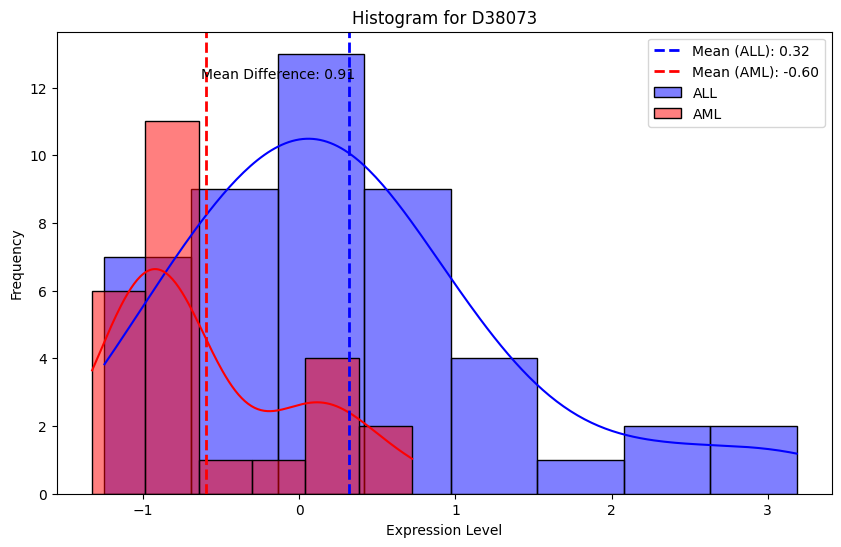

In [29]:
# Select gene expression data for both cancer types
gene_selected = 'D38073_at'
gene_selected_data_all = normalized_merged_XY_ALL[gene_selected]
gene_selected_data_aml = normalized_merged_XY_AML[gene_selected]

# Calculate mean expression for both cancer types
mean_expression_all = gene_selected_data_all.mean()
mean_expression_aml = gene_selected_data_aml.mean()

# Calculate mean difference
mean_difference = abs(mean_expression_all - mean_expression_aml)

# Plot histogram for both cancer types
plt.figure(figsize=(10, 6))

# Plot histogram for ALL
sns.histplot(gene_selected_data_all, color='blue', label='ALL', kde=True)

# Plot histogram for AML
sns.histplot(gene_selected_data_aml, color='red', label='AML', kde=True)

# Annotate mean values
plt.axvline(mean_expression_all, color='blue', linestyle='dashed', linewidth=2, label=f'Mean (ALL): {mean_expression_all:.2f}')
plt.axvline(mean_expression_aml, color='red', linestyle='dashed', linewidth=2, label=f'Mean (AML): {mean_expression_aml:.2f}')

# Annotate mean difference
plt.text((mean_expression_all + mean_expression_aml) / 2, plt.gca().get_ylim()[1]*0.9, f'Mean Difference: {mean_difference:.2f}', ha='center')

# Set labels and title
plt.xlabel('Expression Level')
plt.ylabel('Frequency')
plt.title('Histogram for D38073')

# Add legend
plt.legend()

# Show plot
plt.show()

## **Gene roles**


**ABCC2 Gene (U49248)**

 The ABCC2 gene provides instructions for making a protein called ‘ATP binding cassette subfamily C member 2'. ABCC2 is a part of a family of multidrug resistance proteins responsible for transporting various substances out of cells.

**RBBP4 Gene (X74262)**

The RBBP4 gene encodes for a protein called ‘Retinoblastoma Binding Protein 4’. RBBP4 is a nuclear protein belonging to the subfamily of WD-repeat proteins involved in histone acetylation, chromatin assembly/remodeling, transcriptional repression/silencing.

**MCM3 Gene (D38073)**

 The MCM3 gene encodes a protein known as 'minichromosome maintenance complex component 3'. MCM3 is a member of the protein family essential for the initiation and elongation phases of DNA replication in eukaryotic cells.